# Die Implementierung von ResNet-18

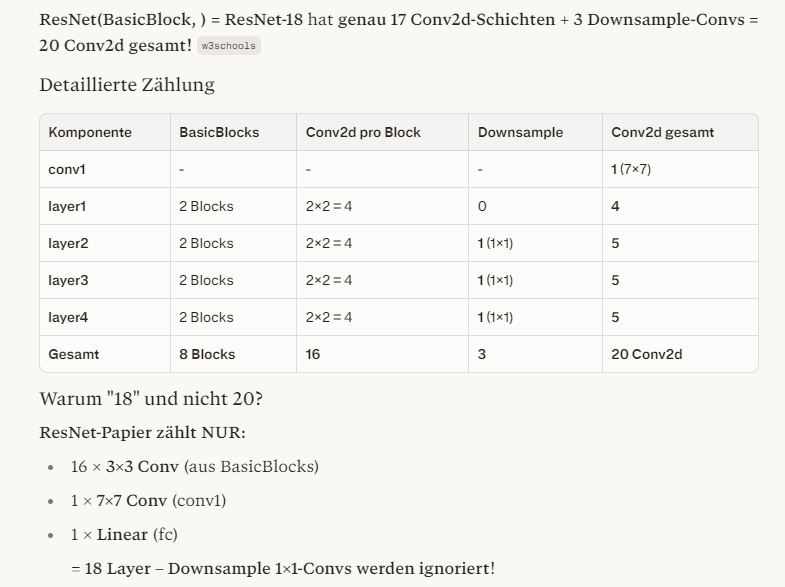


> resnet18()  # [2,2,2,2]   → 8 Blocks

> resnet34()  # [3,4,6,3]   → 16 Blocks

> resnet50()  # [3,4,6,3]   → 16 Bottlenecks (3 Conv pro Block)

> resnet152() # [3,8,36,3]  → 50 Bottlenecks

Trainierst du CIFAR oder ImageNet? ResNet-18 für schnelles Prototyping perfekt!

ImageNet: 224x224x3

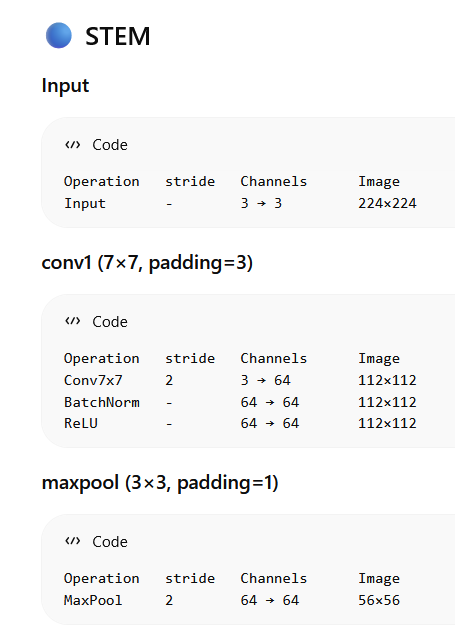

CIFAR10:

ResNet18 (from ImageNet):

Input 32x32x3 (CIFAR10)

    ↓ conv1 (angepasst: 3x3 stride=1) → 32x32x64  
    ↓ Identity (statt maxpool) → 32x32x64
    ↓ layer1 (2 BasicBlocks) → 32x32x64
    ↓ layer2 (2 BasicBlocks) → 16x16x128  
    ↓ layer3 (2 BasicBlocks) → 8x8x256
    ↓ layer4 (2 BasicBlocks) → 4x4x512
    ↓ avgpool (4x4 → 1x1) → 1x1x512
    ↓ fc → Linear(in_features=512, out_features=1000)  # ← HIER!


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def conv3x3(in_planes, out_planes, stride=1):
    """
    3x3 convolution with padding.
    Keeps spatial resolution when stride=1.
    Bias is disabled because BatchNorm is used.
    """
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=1,
        bias=False
    )

class BasicBlock(nn.Module):
    """
    Basic residual block used in ResNet-18 and ResNet-34.

    Structure:
        x -> Conv -> BN -> ReLU -> Conv -> BN -> + -> ReLU
                                 |______________|
                                   skip connection
    """
    expansion = 1  # Output channels = planes * expansion

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()

        # First 3x3 convolution (may change spatial resolution via stride)
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)

        # Second 3x3 convolution (keeps spatial resolution)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)

        # Optional downsampling for the identity (skip) connection
        # Needed if spatial size or number of channels changes
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        # Save input for the skip connection
        identity = x

        # First conv-BN-ReLU
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # Second conv-BN (no ReLU yet)
        out = self.conv2(out)
        out = self.bn2(out)

        # Adjust identity if dimensions do not match
        if self.downsample is not None:
            identity = self.downsample(x)

        # Residual addition (skip connection)
        out += identity

        # Final activation
        out = self.relu(out)

        return out

class ResNet(nn.Module):
    """
    Generic ResNet architecture.

    Args:
        block  : Residual block type (BasicBlock or Bottleneck)
        layers : Number of blocks in each of the 4 layer groups
                 e.g. [2, 2, 2, 2] for ResNet-18
        num_classes : Number of output classes
    """
    def __init__(self, block, layers, num_classes=1000):
        super(ResNet, self).__init__()

        # Number of channels entering the first residual layer
        self.inplanes = 64

        # Initial convolution ("stem")
        # Large 7x7 kernel for fast spatial downsampling
        self.conv1 = nn.Conv2d(
            3, 64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Further spatial downsampling
        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )

        # Four residual layer groups
        self.layer1 = self._make_layer(block, 64,  layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # Global average pooling and classification head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, blocks, stride=1):
        """
        Creates one residual layer group (stage).

        Args:
            block  : Residual block class
            planes : Number of output channels for this layer
            blocks : Number of blocks in this layer
            stride : Stride for the first block (used for downsampling)
        """
        downsample = None

        # Downsample if spatial resolution or channel count changes
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.inplanes,
                    planes * block.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []

        # First block in the layer (may downsample)
        layers.append(block(self.inplanes, planes, stride, downsample))

        # Update number of channels for subsequent blocks
        self.inplanes = planes * block.expansion

        # Remaining blocks (no downsampling)
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Initial feature extraction
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Global average pooling
        x = self.avgpool(x)

        # Flatten and classify
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

def resnet18():
    """
    Constructs a ResNet-18 model.

    ResNet-18 configuration:
        4 stages with 2 BasicBlocks each -> [2, 2, 2, 2]
    """
    return ResNet(BasicBlock, [2, 2, 2, 2])

# Testlauf Code

In [3]:
# Modell erstellen
model = resnet18()

# Beispiel-Eingabe (BatchSize=1, Channels=3, Height=224, Width=224)
dummy_input = torch.randn(1, 3, 224, 224)

# Forward Pass
output = model(dummy_input)

print(f"Eingabe-Form: {dummy_input.shape}")
print(f"Ausgabe-Form (Klassen-Logits): {output.shape}")
# Zeige die ersten 5 Klassen-Wahrscheinlichkeiten
print(f"Erste 5 Logits: {output[0][:5]}")


Eingabe-Form: torch.Size([1, 3, 224, 224])
Ausgabe-Form (Klassen-Logits): torch.Size([1, 1000])
Erste 5 Logits: tensor([ 0.0805, -0.2532,  0.5054, -0.0723,  0.4149], grad_fn=<SliceBackward0>)
